Train/Test Split

In [8]:
import pandas as pd

# Load generated data
final_df = pd.read_csv("../data/raw/prices.csv")

# Prepare TSLA data
tsla = final_df[final_df["Ticker"] == "TSLA"].copy()
tsla["Date"] = pd.to_datetime(tsla["Date"])
tsla = tsla.sort_values("Date")

# Chronological train-test split
train = tsla[tsla["Date"] < "2025-01-01"]["Adj Close"]
test  = tsla[tsla["Date"] >= "2025-01-01"]["Adj Close"]

print("Train period:", train.index.min(), "→", train.index.max())
print("Test period :", test.index.min(), "→", test.index.max())


Train period: 0 → 2515
Test period : 2516 → 2774


ARIMA Model

In [9]:
from pmdarima import auto_arima

model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True
)

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 27 Jan 2026   AIC                          16368.109
Time:                        21:00:34   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):             536.79   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Forecast

In [10]:
forecast = model.predict(n_periods=len(test))


Evaluation

In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.metrics import mae, rmse, mape

print("MAE:", mae(test.values, forecast))
print("RMSE:", rmse(test.values, forecast))
print("MAPE:", mape(test.values, forecast))


MAE: 69.4989569233191
RMSE: 82.93461282588196
MAPE: 22.557915255182202


Visualization

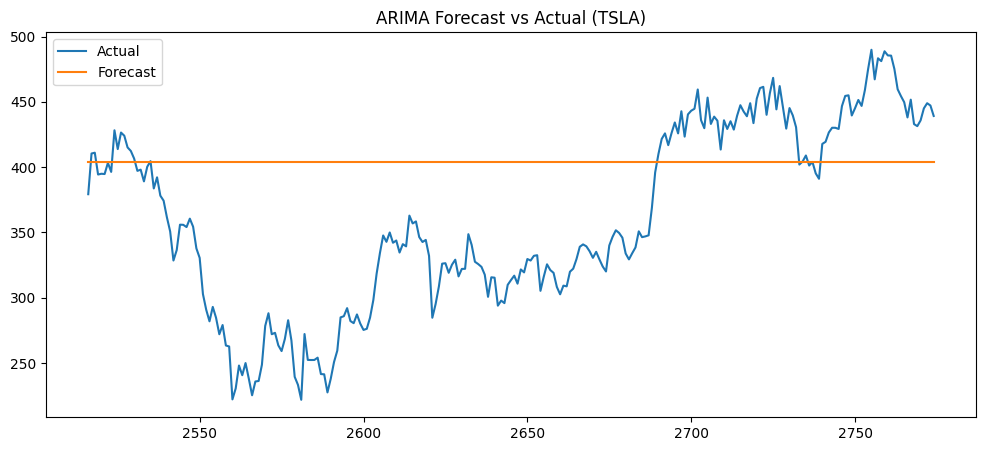

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual (TSLA)")
plt.show()
